In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from wordcloud import WordCloud

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
from google.colab import files
# uploaded = files.upload()
# The file 'fake_job_postings.csv' appears to be already present in the environment.
# Therefore, the interactive upload step can be commented out.

In [42]:
df = pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [43]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (17880, 18)

Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [45]:


df.isnull().sum().sort_values(ascending=False)




,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


In [46]:
print(df['fraudulent'].value_counts())
print("\nPercentage:")
print(df['fraudulent'].value_counts(normalize=True) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64

Percentage:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


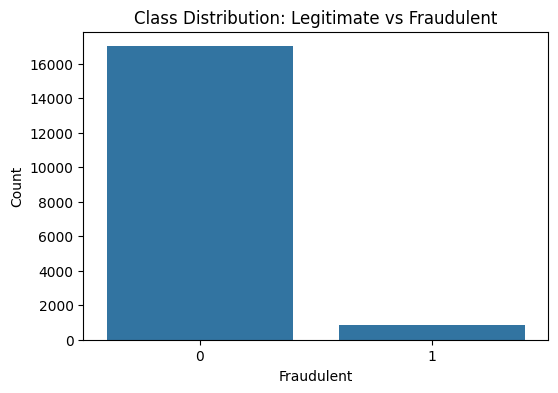

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title("Class Distribution: Legitimate vs Fraudulent")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()

In [48]:
text_cols = [
    'title', 'location', 'department', 'salary_range', 'company_profile',
    'description', 'requirements', 'benefits', 'employment_type',
    'required_experience', 'required_education', 'industry', 'function'
]

for col in text_cols:
    df[col] = df[col].fillna('')

In [49]:
structured_cols = ['telecommuting', 'has_company_logo', 'has_questions']

for col in structured_cols:
    df[col] = df[col].fillna(0)

In [50]:
df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


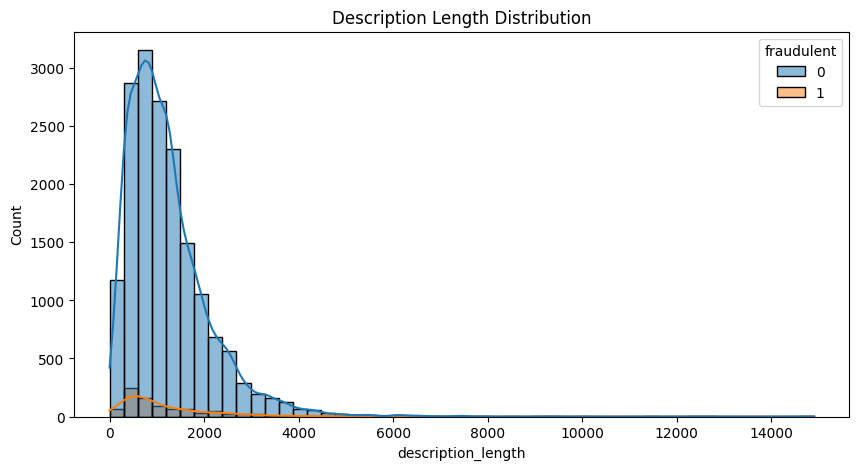

In [51]:
df['description_length'] = df['description'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='description_length', hue='fraudulent', bins=50, kde=True)
plt.title("Description Length Distribution")
plt.show()

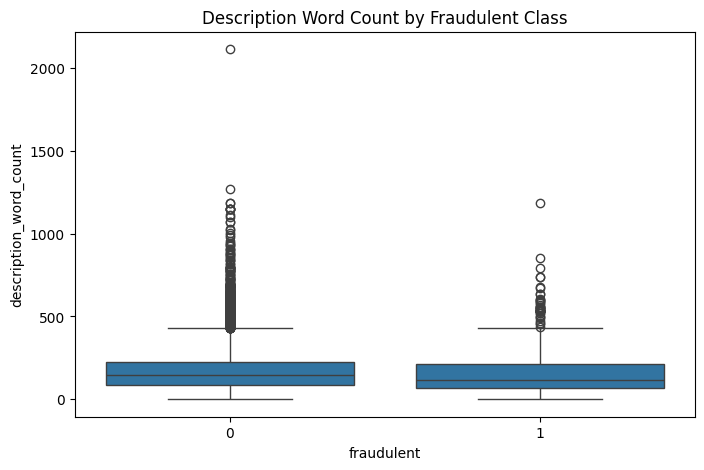

In [52]:
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(x='fraudulent', y='description_word_count', data=df)
plt.title("Description Word Count by Fraudulent Class")
plt.show()

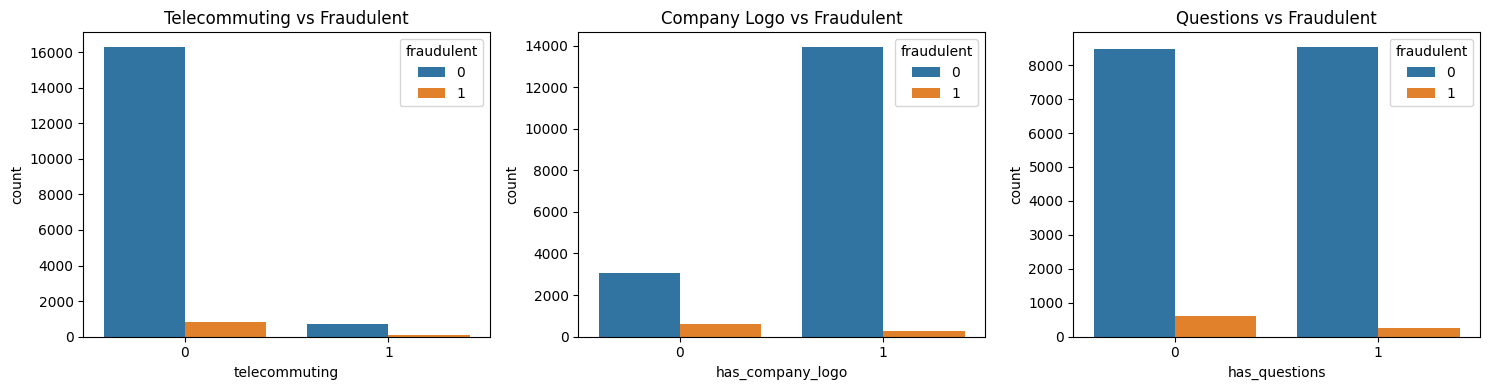

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(x='telecommuting', hue='fraudulent', data=df, ax=axes[0])
axes[0].set_title("Telecommuting vs Fraudulent")

sns.countplot(x='has_company_logo', hue='fraudulent', data=df, ax=axes[1])
axes[1].set_title("Company Logo vs Fraudulent")

sns.countplot(x='has_questions', hue='fraudulent', data=df, ax=axes[2])
axes[2].set_title("Questions vs Fraudulent")

plt.tight_layout()
plt.show()

In [54]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'#url_[a-zA-Z0-9_]+#', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

In [55]:
df['combined_text'] = (
    df['title'] + ' ' +
    df['location'] + ' ' +
    df['department'] + ' ' +
    df['salary_range'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits'] + ' ' +
    df['employment_type'] + ' ' +
    df['required_experience'] + ' ' +
    df['required_education'] + ' ' +
    df['industry'] + ' ' +
    df['function']
)

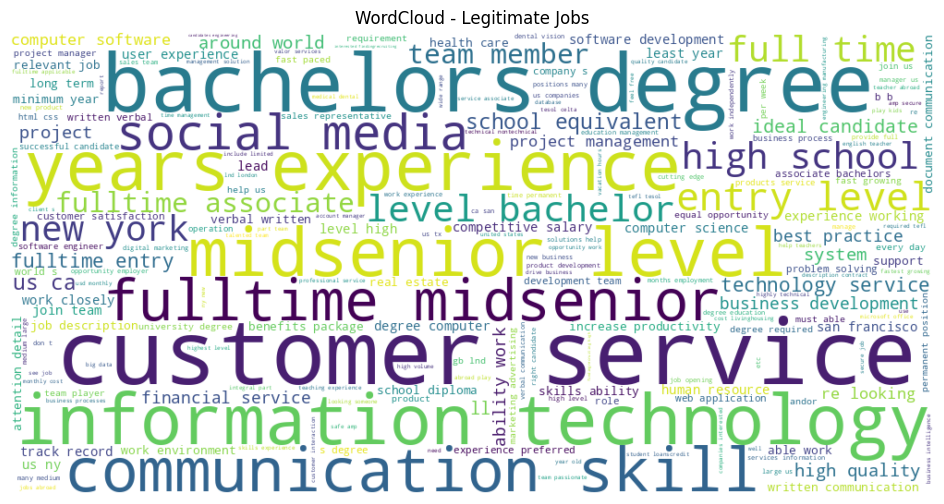

In [56]:
df['cleaned_text'] = df['combined_text'].apply(clean_text)

legit_text = " ".join(df[df['fraudulent'] == 0]['cleaned_text'].astype(str))

wordcloud_legit = WordCloud(width=1000, height=500, background_color='white').generate(legit_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud_legit, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Legitimate Jobs")
plt.show()

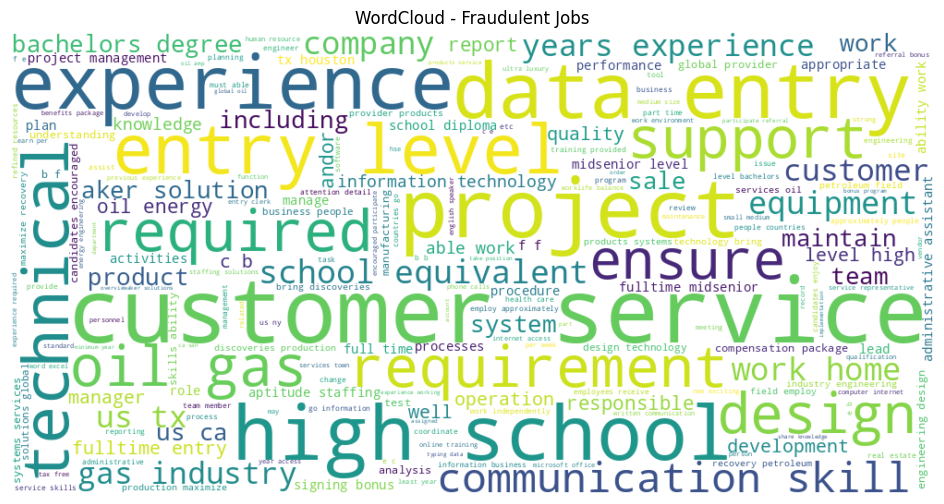

In [57]:
fraud_text = " ".join(df[df['fraudulent'] == 1]['cleaned_text'].astype(str))

wordcloud_fraud = WordCloud(width=1000, height=500, background_color='white').generate(fraud_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud_fraud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Fraudulent Jobs")
plt.show()

In [58]:
X = df[['cleaned_text', 'telecommuting', 'has_company_logo', 'has_questions']]
y = df['fraudulent']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (14304, 4)
Testing shape: (3576, 4)


In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=10000, ngram_range=(1,2)), 'cleaned_text'),
        ('num', 'passthrough', ['telecommuting', 'has_company_logo', 'has_questions'])
    ]
)

In [61]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy : 0.9608501118568232
Precision: 0.56
Recall   : 0.8901734104046243
F1 Score : 0.6875
ROC AUC  : 0.9912657821473403

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.56      0.89      0.69       173

    accuracy                           0.96      3576
   macro avg       0.78      0.93      0.83      3576
weighted avg       0.97      0.96      0.97      3576



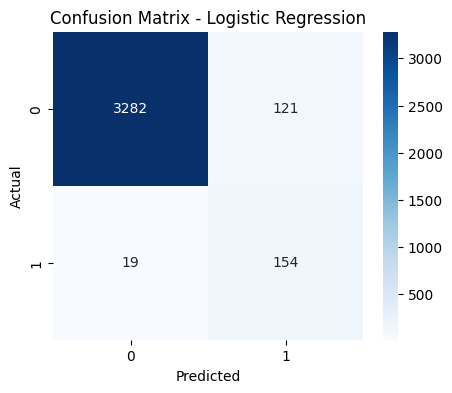

In [62]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
X_text = df['cleaned_text']
y = df['fraudulent']

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

nb_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('classifier', MultinomialNB())
])

nb_model.fit(X_train_text, y_train_text)

y_pred_nb = nb_model.predict(X_test_text)
y_prob_nb = nb_model.predict_proba(X_test_text)[:, 1]

print("Naive Bayes Results")
print("Accuracy :", accuracy_score(y_test_text, y_pred_nb))
print("Precision:", precision_score(y_test_text, y_pred_nb))
print("Recall   :", recall_score(y_test_text, y_pred_nb))
print("F1 Score :", f1_score(y_test_text, y_pred_nb))
print("ROC AUC  :", roc_auc_score(y_test_text, y_prob_nb))
print("\nClassification Report:\n")
print(classification_report(y_test_text, y_pred_nb))

Naive Bayes Results
Accuracy : 0.9619686800894854
Precision: 0.7228915662650602
Recall   : 0.3468208092485549
F1 Score : 0.46875
ROC AUC  : 0.934002469769109

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3403
           1       0.72      0.35      0.47       173

    accuracy                           0.96      3576
   macro avg       0.85      0.67      0.72      3576
weighted avg       0.96      0.96      0.96      3576



In [64]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.9804250559284117
Precision: 0.9904761904761905
Recall   : 0.6011560693641619
F1 Score : 0.7482014388489209
ROC AUC  : 0.9917736645156687

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.60      0.75       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



In [65]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test_text, y_pred_nb),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test_text, y_pred_nb),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test_text, y_pred_nb),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test_text, y_pred_nb),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test_text, y_prob_nb),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.980425,0.990476,0.601156,0.748201,0.991774
0,Logistic Regression,0.960850,0.560000,0.890173,0.687500,0.991266
1,Naive Bayes,0.961969,0.722892,0.346821,0.468750,0.934002


In [66]:
df['raw_combined_text'] = (
    df['title'] + ' ' +
    df['location'] + ' ' +
    df['department'] + ' ' +
    df['salary_range'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits'] + ' ' +
    df['employment_type'] + ' ' +
    df['required_experience'] + ' ' +
    df['required_education'] + ' ' +
    df['industry'] + ' ' +
    df['function']
)

X_raw = df[['raw_combined_text', 'telecommuting', 'has_company_logo', 'has_questions']]
y = df['fraudulent']

raw_preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=10000, ngram_range=(1,2)), 'raw_combined_text'),
        ('num', 'passthrough', ['telecommuting', 'has_company_logo', 'has_questions'])
    ]
)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

lr_raw_model = Pipeline([
    ('preprocessor', raw_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_raw_model.fit(X_train_raw, y_train_raw)
y_pred_raw = lr_raw_model.predict(X_test_raw)

print("Raw Text Accuracy:", accuracy_score(y_test_raw, y_pred_raw))
print("Raw Text F1 Score:", f1_score(y_test_raw, y_pred_raw))

Raw Text Accuracy: 0.9639261744966443
Raw Text F1 Score: 0.7101123595505618


In [67]:
param_grid = {
    'preprocessor__text__max_features': [5000, 10000],
    'preprocessor__text__ngram_range': [(1,1), (1,2)],
    'classifier__C': [0.1, 1, 10]
}

grid_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

grid_search = GridSearchCV(
    grid_model,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'classifier__C': 10, 'preprocessor__text__max_features': 10000, 'preprocessor__text__ngram_range': (1, 1)}
Best CV F1 Score: 0.7830102832533589


In [68]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Tuned Logistic Regression Results
Accuracy : 0.9846196868008948
Precision: 0.8105263157894737
Recall   : 0.8901734104046243
F1 Score : 0.8484848484848485
ROC AUC  : 0.9944149925516249

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.81      0.89      0.85       173

    accuracy                           0.98      3576
   macro avg       0.90      0.94      0.92      3576
weighted avg       0.99      0.98      0.98      3576



In [74]:
tfidf_vectorizer = best_model.named_steps['preprocessor'].named_transformers_['text']
classifier = best_model.named_steps['classifier']

feature_names_text = tfidf_vectorizer.get_feature_names_out()
coefficients = classifier.coef_[0]

top_fraud_idx = np.argsort(coefficients)[-20:]
top_legit_idx = np.argsort(coefficients)[:20]

top_fraud_words = pd.DataFrame({
    'Word': feature_names_text[top_fraud_idx],
    'Coefficient': coefficients[top_fraud_idx]
}).sort_values(by='Coefficient', ascending=False)

top_legit_words = pd.DataFrame({
    'Word': feature_names_text[top_legit_idx],
    'Coefficient': coefficients[top_legit_idx]
}).sort_values(by='Coefficient', ascending=True)

print("Top words indicating fraudulent jobs:")
print(top_fraud_words)

print("\nTop words indicating legitimate jobs:")
print(top_legit_words)

Top words indicating fraudulent jobs:
              Word  Coefficient
19          accion     9.911372
18            link     8.503293
17           money     7.014230
16           entry     6.821581
15        novation     6.800717
14        aptitude     6.101288
13            gary     5.965448
12             oil     5.923697
11       financing     5.920989
10  administrative     5.740022
9            wages     5.672828
8               fc     5.356573
7           subsea     5.061404
6         supplier     4.917032
5         hospital     4.909403
4             earn     4.712491
3       encouraged     4.700371
2         surgical     4.693496
1            kuala     4.656560
0             aker     4.578309

Top words indicating legitimate jobs:
                 Word  Coefficient
0           companies    -6.541800
1            software    -4.773160
2           associate    -4.745755
3                team    -4.650306
4              search    -4.399538
5             english    -4.254520
6   fi

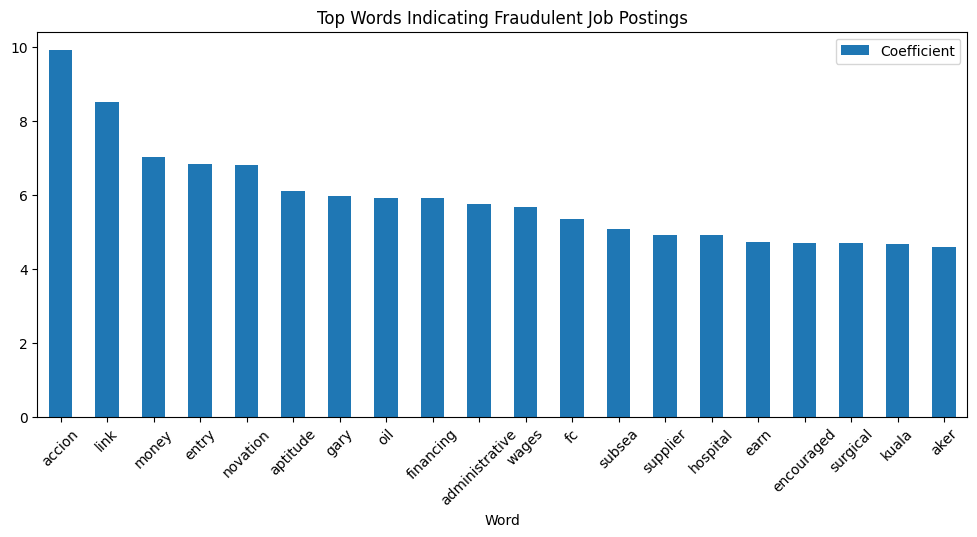

In [69]:
top_fraud_words.plot(x='Word', y='Coefficient', kind='bar', figsize=(12,5))
plt.title("Top Words Indicating Fraudulent Job Postings")
plt.xticks(rotation=45)
plt.show()

In [70]:
def predict_job_posting(title, location, department, salary_range, company_profile,
                        description, requirements, benefits, employment_type,
                        required_experience, required_education, industry, function,
                        telecommuting, has_company_logo, has_questions):

    combined_text = " ".join([
        str(title), str(location), str(department), str(salary_range),
        str(company_profile), str(description), str(requirements),
        str(benefits), str(employment_type), str(required_experience),
        str(required_education), str(industry), str(function)
    ])

    cleaned_text = clean_text(combined_text)

    input_df = pd.DataFrame([{
        'cleaned_text': cleaned_text,
        'telecommuting': telecommuting,
        'has_company_logo': has_company_logo,
        'has_questions': has_questions
    }])

    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0][1]

    label = "Fraudulent Job Posting" if prediction == 1 else "Legitimate Job Posting"

    return {
        "Prediction": label,
        "Fraud Probability": round(probability, 4)
    }

In [71]:
sample1 = predict_job_posting(
    title="Data Entry Clerk",
    location="US, Remote",
    department="",
    salary_range="",
    company_profile="Fast growing company",
    description="Earn money quickly from home. No experience required. Immediate start.",
    requirements="No special skills needed",
    benefits="High salary, flexible timing",
    employment_type="Part-time",
    required_experience="Not Applicable",
    required_education="High School",
    industry="",
    function="Administrative",
    telecommuting=1,
    has_company_logo=0,
    has_questions=0
)

print(sample1)

{'Prediction': 'Fraudulent Job Posting', 'Fraud Probability': np.float64(0.9994)}


In [72]:
sample2 = predict_job_posting(
    title="Software Engineer",
    location="IN, Gujarat, Surat",
    department="Engineering",
    salary_range="",
    company_profile="Established product-based software company",
    description="We are looking for a Python developer with strong knowledge of APIs, SQL, and backend development.",
    requirements="Bachelor degree, Python, SQL, REST API, problem-solving",
    benefits="Health insurance, PF, paid leave",
    employment_type="Full-time",
    required_experience="2 years",
    required_education="Bachelor's Degree",
    industry="Information Technology",
    function="Engineering",
    telecommuting=0,
    has_company_logo=1,
    has_questions=1
)

print(sample2)

{'Prediction': 'Legitimate Job Posting', 'Fraud Probability': np.float64(0.0045)}


In [73]:
import joblib

joblib.dump(best_model, "fake_job_detection_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [75]:
from google.colab import files
files.download("fake_job_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
print("""
PROJECT CONCLUSION

1. The dataset was analyzed for missing values, class imbalance, and text distributions.
2. Textual features such as title, description, requirements, and company profile were combined.
3. Text was cleaned using lowercasing, punctuation removal, URL removal, and stopword removal.
4. TF-IDF was used to transform textual data into numerical features.
5. Structured features like telecommuting, company logo, and screening questions were also included.
6. Multiple models were trained: Logistic Regression, Naive Bayes, and Random Forest.
7. Models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
8. Comparative analysis was performed to identify the best model.
9. Hyperparameter tuning improved the best-performing model.
10. A final prediction system was created to classify unseen job postings as fraudulent or legitimate.

LIMITATIONS
- Fraud patterns can change over time.
- Some fraudulent posts may look professional.
- Some real posts may appear suspicious.
- The model depends on the quality of training data.
- External verification signals like recruiter history, domain trust, and company website are not included.
""")


PROJECT CONCLUSION

1. The dataset was analyzed for missing values, class imbalance, and text distributions.
2. Textual features such as title, description, requirements, and company profile were combined.
3. Text was cleaned using lowercasing, punctuation removal, URL removal, and stopword removal.
4. TF-IDF was used to transform textual data into numerical features.
5. Structured features like telecommuting, company logo, and screening questions were also included.
6. Multiple models were trained: Logistic Regression, Naive Bayes, and Random Forest.
7. Models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
8. Comparative analysis was performed to identify the best model.
9. Hyperparameter tuning improved the best-performing model.
10. A final prediction system was created to classify unseen job postings as fraudulent or legitimate.

LIMITATIONS
- Fraud patterns can change over time.
- Some fraudulent posts may look professional.
- Some real posts may appear 